# Chicago Crimes EDA — Neighborhood Analysis

**Target Neighborhoods:** Logan Square, Chatham, South Chicago, Morgan Park, Wicker Park, Humboldt Park, Woodlawn, Lakeview, Loop, Uptown  
**Data Source:** [Chicago Data Portal — Crimes 2001 to Present](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2)

## 1. Imports & Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sodapy import Socrata
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14

# ── Paste your Chicago Data Portal app token here ──────────────
APP_TOKEN = 'Dpp1StQZt6kUf8cPF3eI4epyA'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Define Target Neighborhoods & Community Area Codes

In [2]:
# Chicago community area numbers for the target neighborhoods
COMMUNITY_AREAS = {
    22: 'Logan Square',
    44: 'Chatham',
    46: 'South Chicago',
    75: 'Morgan Park',
    24: 'Wicker Park',
    23: 'Humboldt Park',
    42: 'Woodlawn',
     6: 'Lakeview',
    32: 'Loop',
     3: 'Uptown',
}

# Socrata stores community_area as a string — values must be quoted in SoQL
area_filter = ', '.join(f"'{k}'" for k in COMMUNITY_AREAS.keys())

print(f'Target neighborhoods : {list(COMMUNITY_AREAS.values())}')
print(f'SoQL area filter     : {area_filter}')

Target neighborhoods : ['Logan Square', 'Chatham', 'South Chicago', 'Morgan Park', 'Wicker Park', 'Humboldt Park', 'Woodlawn', 'Lakeview', 'Loop', 'Uptown']
SoQL area filter     : '22', '44', '46', '75', '24', '23', '42', '6', '32', '3'


## 3. Fetch Last 6 Months of Data from the Chicago Data Portal (Socrata API)

In [3]:
# Compute the date 6 months ago
six_months_ago = (datetime.now() - timedelta(days=180)).strftime('%Y-%m-%dT00:00:00.000')
today          = datetime.now().strftime('%Y-%m-%d')

soql_where = (
    f"community_area in({area_filter}) "
    f"AND date >= '{six_months_ago}'"
)

print(f'Fetching data from : {six_months_ago[:10]}  →  {today}')
print(f'SoQL WHERE clause  : {soql_where}')

Fetching data from : 2025-08-29  →  2026-02-25
SoQL WHERE clause  : community_area in('22', '44', '46', '75', '24', '23', '42', '6', '32', '3') AND date >= '2025-08-29T00:00:00.000'


In [6]:
client = Socrata('data.cityofchicago.org', APP_TOKEN)

print('Fetching records …')
results = client.get(
    'ijzp-q8t2',
    where=soql_where,
    limit=500_000,       # safety ceiling; 6-month window is well under this
    order='date DESC'
)

df_raw = pd.DataFrame.from_records(results)
print(f'Records fetched : {len(df_raw):,}')
print(f'Columns         : {list(df_raw.columns)}')

Fetching records …
Records fetched : 22,156
Columns         : ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


## 4. Data Cleaning & Type Casting

In [7]:
df = df_raw.copy()

# ── Date/time ──────────────────────────────────────────────────
df['date']        = pd.to_datetime(df['date'], errors='coerce')
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b %Y')   # e.g. 'Aug 2024'
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend']  = df['date'].dt.dayofweek >= 5      # Sat=5, Sun=6

# ── Numeric coercions ─────────────────────────────────────────
for col in ['community_area', 'beat', 'district', 'ward']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['latitude', 'longitude', 'x_coordinate', 'y_coordinate']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Boolean ───────────────────────────────────────────────────
for col in ['arrest', 'domestic']:
    if col in df.columns:
        df[col] = df[col].map({'true': True, 'false': False, True: True, False: False})

# ── Neighborhood label ────────────────────────────────────────
df['neighborhood'] = df['community_area'].map(COMMUNITY_AREAS)

# ── String normalisation ──────────────────────────────────────
for col in ['primary_type', 'description', 'location_description', 'block']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.upper()

print(f'Shape after cleaning : {df.shape}')
print(f'Date range           : {df["date"].min()} → {df["date"].max()}')
print(f'Null values (non-zero):\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Shape after cleaning : (22156, 28)
Date range           : 2025-08-29 00:00:00 → 2026-02-17 00:00:00
Null values (non-zero):
location_description    157
x_coordinate             20
y_coordinate             20
latitude                 20
longitude                20
location                 20
dtype: int64


## 5. Dataset Overview

In [8]:
print('=== Shape ===')
print(df.shape)

print('\n=== dtypes ===')
print(df.dtypes)

print('\n=== First 5 rows ===')
df.head()

=== Shape ===
(22156, 28)

=== dtypes ===
id                                 str
case_number                        str
date                    datetime64[us]
block                              str
iucr                               str
primary_type                       str
description                        str
location_description               str
arrest                            bool
domestic                          bool
beat                             int64
district                         int64
ward                             int64
community_area                   int64
fbi_code                           str
x_coordinate                   float64
y_coordinate                   float64
year                             int32
updated_on                         str
latitude                       float64
longitude                      float64
location                        object
month                            int32
month_name                         str
hour                  

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,latitude,longitude,location,month,month_name,hour,day_of_week,is_weekend,neighborhood
0,14113132,JK152368,2026-02-17 00:00:00,030XX N KENMORE AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,VEHICLE NON-COMMERCIAL,False,False,...,2026-02-24T15:41:25.000,41.937095,-87.655226,"{'latitude': '41.937095103', 'longitude': '-87...",2,Feb 2026,0,Tuesday,False,Lakeview
1,14113053,JK152214,2026-02-17 00:00:00,023XX W RICE ST,1581,SEX OFFENSE,NON-CONSENSUAL DISSEMINATION OF PRIVATE SEXUAL...,APARTMENT,False,True,...,2026-02-24T15:41:25.000,41.896690,-87.685306,"{'latitude': '41.896689903', 'longitude': '-87...",2,Feb 2026,0,Tuesday,False,Wicker Park
2,14113041,JK152195,2026-02-17 00:00:00,016XX W NORTH AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,2026-02-24T15:41:25.000,41.910625,-87.667998,"{'latitude': '41.910624936', 'longitude': '-87...",2,Feb 2026,0,Tuesday,False,Wicker Park
3,14113079,JK152215,2026-02-17 00:00:00,023XX W RICE ST,1242,DECEPTIVE PRACTICE,COMPUTER FRAUD,APARTMENT,False,False,...,2026-02-24T15:41:25.000,41.896690,-87.685306,"{'latitude': '41.896689903', 'longitude': '-87...",2,Feb 2026,0,Tuesday,False,Wicker Park
4,14115135,JK154674,2026-02-16 23:59:00,039XX N ASHLAND AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,2026-02-24T15:41:25.000,41.952977,-87.669013,"{'latitude': '41.952976889', 'longitude': '-87...",2,Feb 2026,23,Monday,False,Lakeview


In [9]:
print('=== Basic statistics ===')
df.describe(include='all')

=== Basic statistics ===


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,latitude,longitude,location,month,month_name,hour,day_of_week,is_weekend,neighborhood
count,22156,22156,22156,22156,22156,22156,22156,21999,22156,22156,...,22156,22136.000000,22136.000000,22136,22156.000000,22156,22156.000000,22156,22156,22156
unique,22156,22156,NaN,3842,253,29,236,92,2,2,...,327,NaN,NaN,11951,NaN,7,NaN,7,2,10
top,14113132,JK152368,NaN,001XX N STATE ST,0860,THEFT,SIMPLE,STREET,False,False,...,2025-11-02T15:41:09.000,NaN,NaN,"{'latitude': '41.929743818', 'longitude': '-87...",NaN,Oct 2025,NaN,Friday,False,Loop
freq,1,1,NaN,264,1721,6150,2824,5728,18831,19010,...,6950,NaN,NaN,115,NaN,4475,NaN,3372,15797,3779
mean,NaN,NaN,2025-11-18 03:21:44.092796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.863820,-87.649176,NaN,8.163432,NaN,12.654541,NaN,NaN,NaN
min,NaN,NaN,2025-08-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.677397,-87.742422,NaN,1.000000,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,2025-10-05 16:38:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.777945,-87.681160,NaN,8.000000,NaN,8.000000,NaN,NaN,NaN
50%,NaN,NaN,2025-11-14 17:06:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.892776,-87.650070,NaN,10.000000,NaN,14.000000,NaN,NaN,NaN
75%,NaN,NaN,2025-12-30 15:05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.920519,-87.624188,NaN,11.000000,NaN,18.000000,NaN,NaN,NaN
max,NaN,NaN,2026-02-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.976849,-87.532230,NaN,12.000000,NaN,23.000000,NaN,NaN,NaN


## 6. Missing Value Analysis

                      missing_count  missing_%
location_description            157       0.71
x_coordinate                     20       0.09
location                         20       0.09
longitude                        20       0.09
latitude                         20       0.09
y_coordinate                     20       0.09


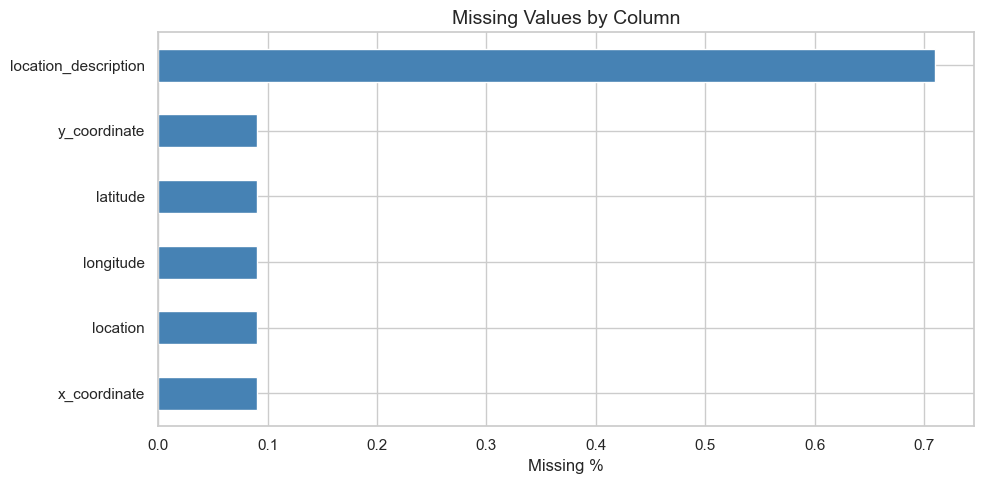

In [10]:
missing     = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df  = missing_df[missing_df['missing_count'] > 0]

print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
missing_df['missing_%'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

## 7. Crime Count per Neighborhood

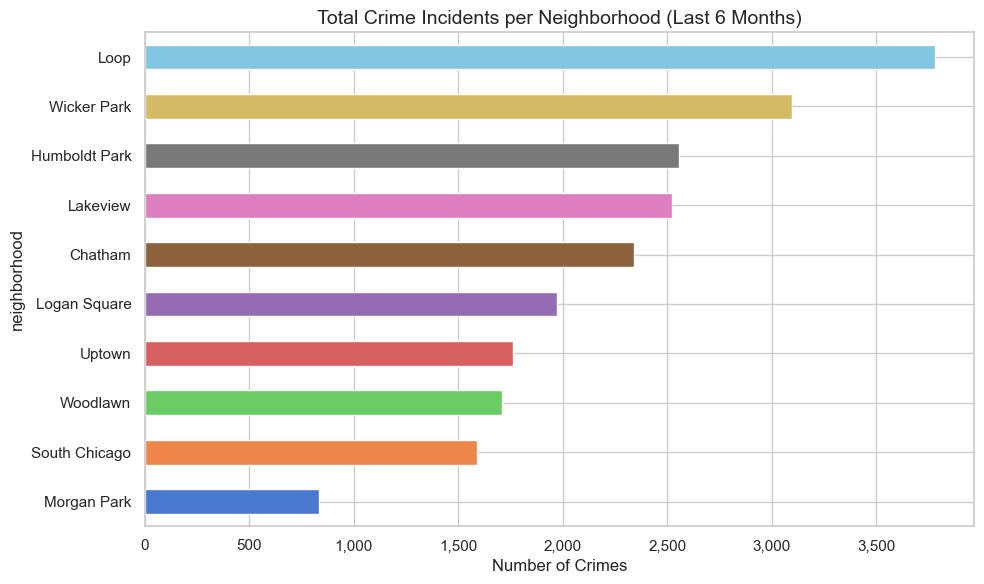

neighborhood
Loop             3779
Wicker Park      3096
Humboldt Park    2555
Lakeview         2521
Chatham          2340
Logan Square     1973
Uptown           1763
Woodlawn         1708
South Chicago    1588
Morgan Park       833


In [11]:
hood_counts = df['neighborhood'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
hood_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(hood_counts)))
ax.set_xlabel('Number of Crimes')
ax.set_title('Total Crime Incidents per Neighborhood (Last 6 Months)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(hood_counts.sort_values(ascending=False).to_string())

## 8. Top Crime Types (Overall)

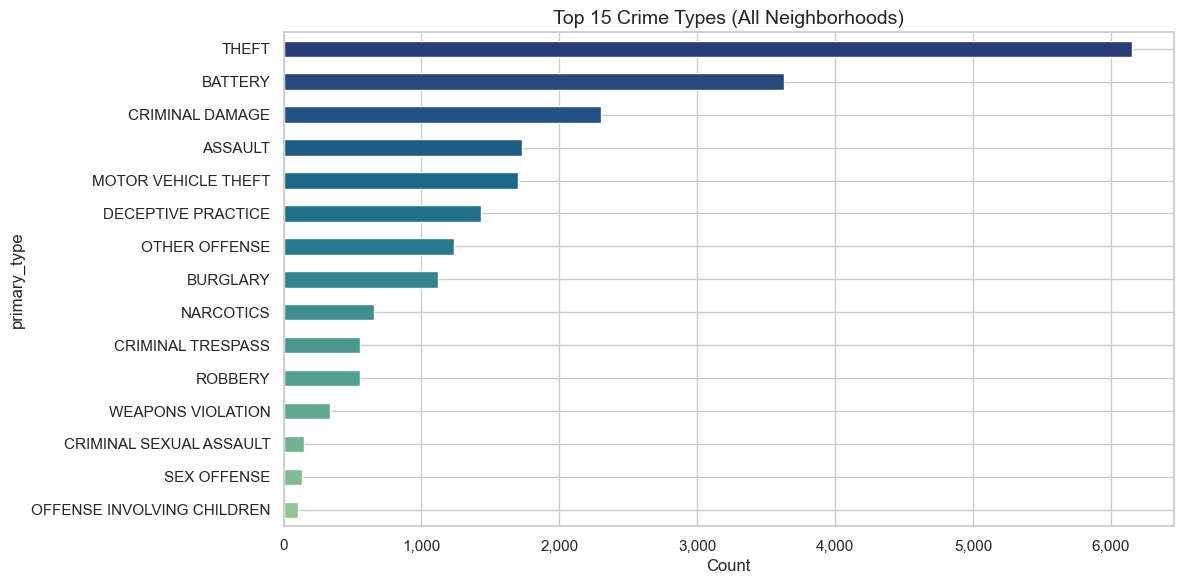

In [12]:
top_types = df['primary_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_types.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('crest', 15))
ax.set_xlabel('Count')
ax.set_title('Top 15 Crime Types (All Neighborhoods)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 9. Most Common Crime per Neighborhood

In [13]:
top_crime_per_hood = (
    df.groupby(['neighborhood', 'primary_type'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .groupby('neighborhood')
      .first()
      .reset_index()
      .rename(columns={'primary_type': 'top_crime', 'count': 'occurrences'})
      .sort_values('occurrences', ascending=False)
)

print(top_crime_per_hood[['neighborhood', 'top_crime', 'occurrences']].to_string(index=False))

 neighborhood top_crime  occurrences
         Loop     THEFT         1437
     Lakeview     THEFT         1053
  Wicker Park     THEFT          968
 Logan Square     THEFT          692
       Uptown     THEFT          546
Humboldt Park   BATTERY          526
      Chatham   BATTERY          499
South Chicago   BATTERY          341
     Woodlawn   BATTERY          333
  Morgan Park     THEFT          184


## 10. Top Crime Types per Neighborhood (Heatmap)

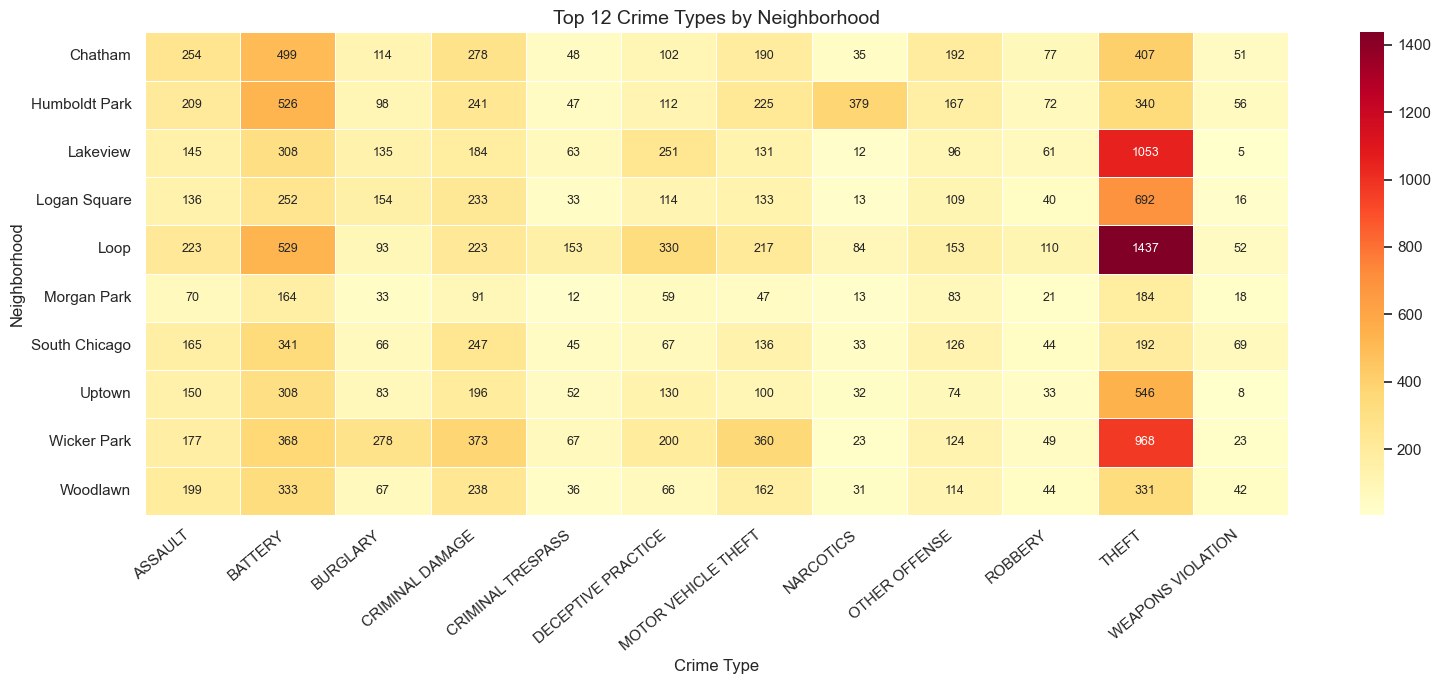

In [14]:
top_n          = 12
top_crime_types = df['primary_type'].value_counts().head(top_n).index

pivot = (
    df[df['primary_type'].isin(top_crime_types)]
      .groupby(['neighborhood', 'primary_type'])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot,
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title(f'Top {top_n} Crime Types by Neighborhood')
ax.set_xlabel('Crime Type')
ax.set_ylabel('Neighborhood')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## 11. Crime Composition per Neighborhood (100% Stacked Bar)

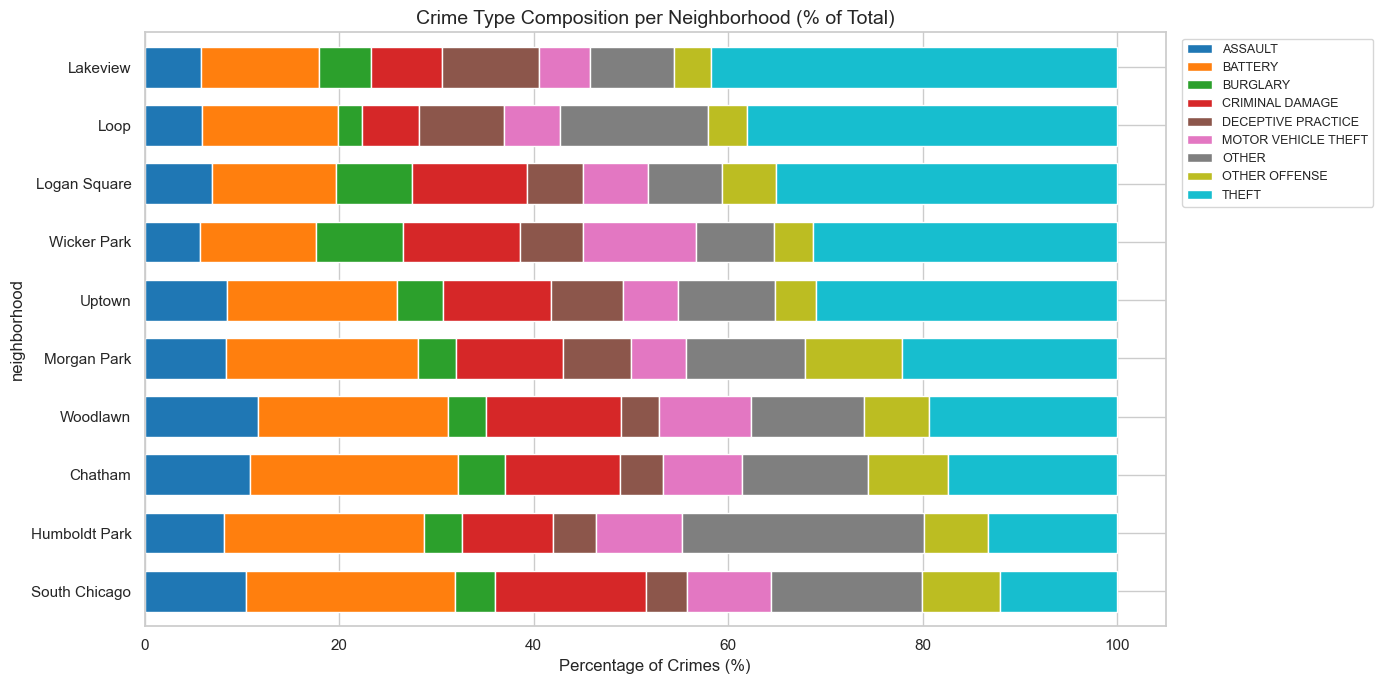

In [15]:
# Use top 8 crime types; group the rest as 'OTHER'
top8 = df['primary_type'].value_counts().head(8).index.tolist()

df['crime_grouped'] = df['primary_type'].where(df['primary_type'].isin(top8), other='OTHER')

composition = (
    df.groupby(['neighborhood', 'crime_grouped'])
      .size()
      .unstack(fill_value=0)
)
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
composition_pct.sort_values(top8[0], ascending=True).plot(
    kind='barh', stacked=True, ax=ax,
    colormap='tab10', width=0.7
)
ax.set_xlabel('Percentage of Crimes (%)')
ax.set_title('Crime Type Composition per Neighborhood (% of Total)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Arrest Rate per Neighborhood

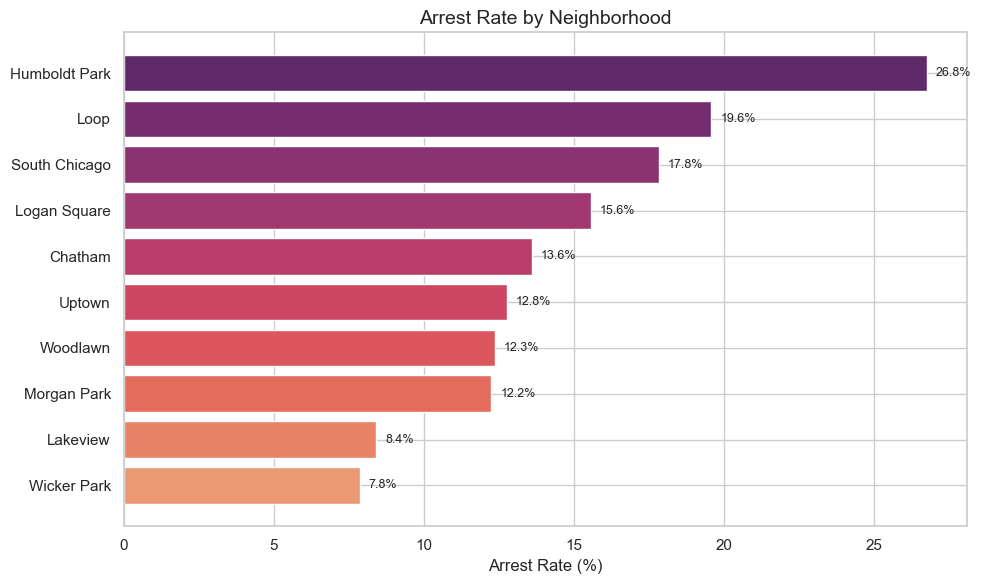

               arrests  total  arrest_rate_%
neighborhood                                
Humboldt Park      684   2555          26.77
Loop               740   3779          19.58
South Chicago      283   1588          17.82
Logan Square       307   1973          15.56
Chatham            318   2340          13.59
Uptown             225   1763          12.76
Woodlawn           211   1708          12.35
Morgan Park        102    833          12.24
Lakeview           212   2521           8.41
Wicker Park        243   3096           7.85


In [16]:
arrest_rate = (
    df.groupby('neighborhood')['arrest']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'arrests', 'count': 'total'})
)
arrest_rate['arrest_rate_%'] = (arrest_rate['arrests'] / arrest_rate['total'] * 100).round(2)
arrest_rate = arrest_rate.sort_values('arrest_rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(arrest_rate.index, arrest_rate['arrest_rate_%'],
        color=sns.color_palette('flare', len(arrest_rate)))
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Neighborhood')
for i, (val, _) in enumerate(zip(arrest_rate['arrest_rate_%'], arrest_rate.index)):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(arrest_rate[['arrests', 'total', 'arrest_rate_%']].sort_values('arrest_rate_%', ascending=False))

## 13. Arrest Rate by Crime Type

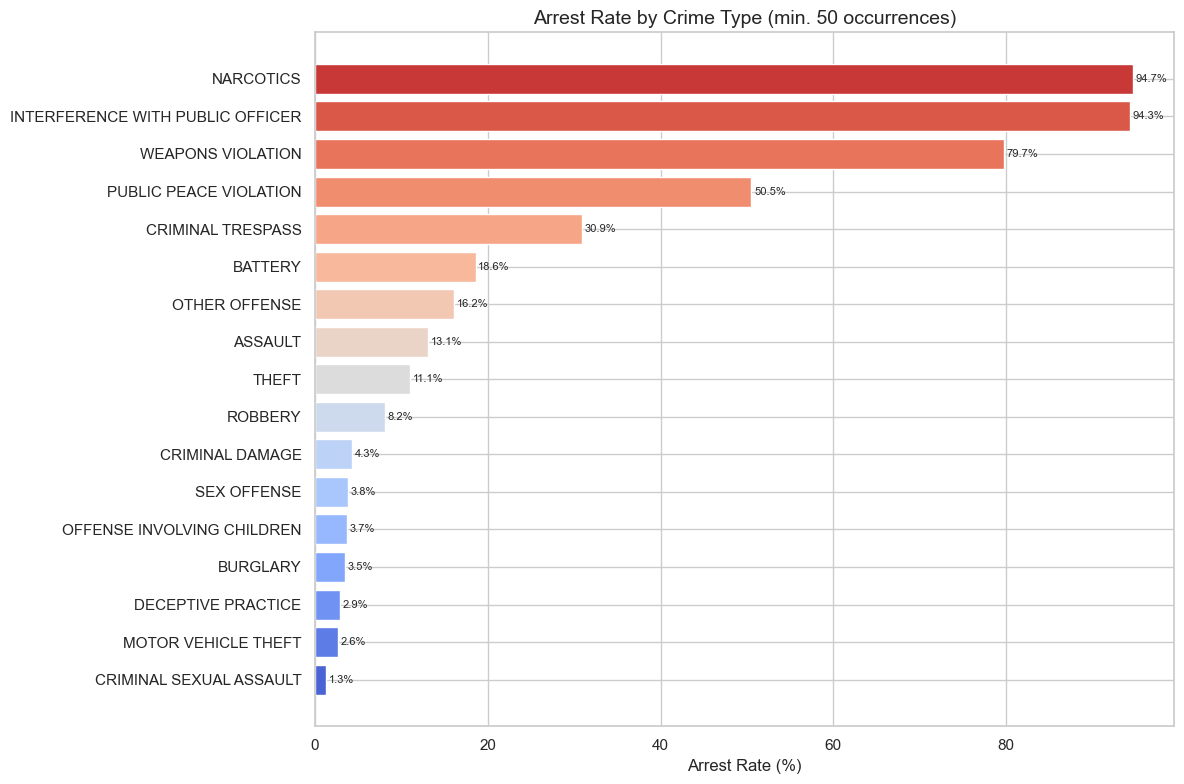

In [17]:
arrest_by_type = (
    df.groupby('primary_type')['arrest']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'arrests', 'count': 'total'})
)
arrest_by_type['arrest_rate_%'] = (arrest_by_type['arrests'] / arrest_by_type['total'] * 100).round(2)
# Keep only crime types with at least 50 occurrences to avoid noise
arrest_by_type = arrest_by_type[arrest_by_type['total'] >= 50].sort_values('arrest_rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(arrest_by_type.index, arrest_by_type['arrest_rate_%'],
        color=sns.color_palette('coolwarm', len(arrest_by_type)))
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (min. 50 occurrences)')
for i, val in enumerate(arrest_by_type['arrest_rate_%']):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 14. Domestic vs. Non-Domestic Crimes per Neighborhood

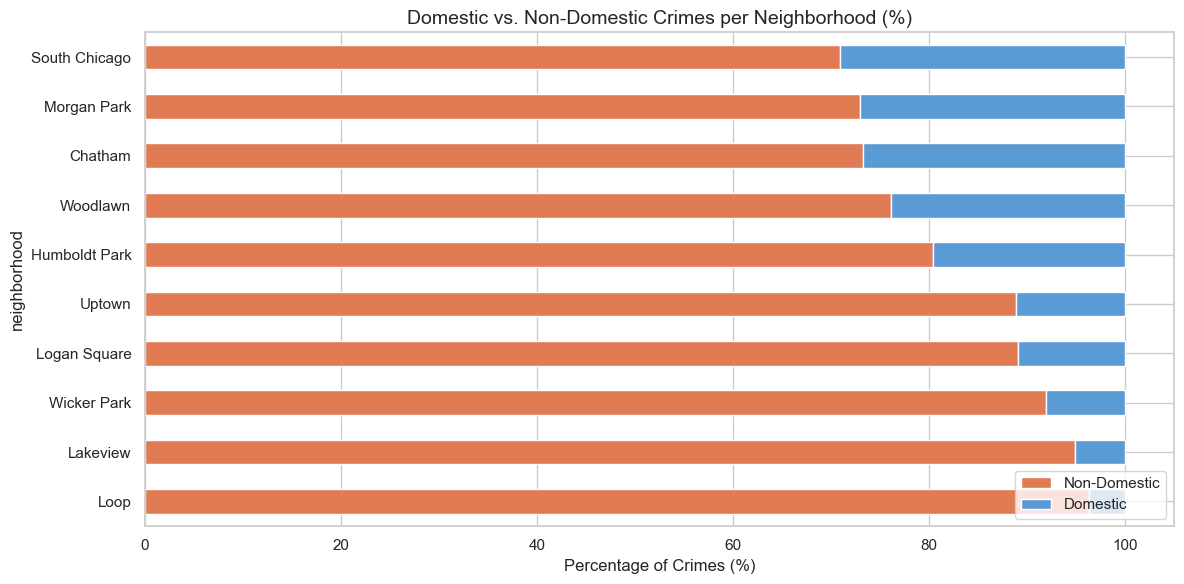

In [18]:
domestic = (
    df.groupby(['neighborhood', 'domestic'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={True: 'Domestic', False: 'Non-Domestic'})
)
domestic_pct = domestic.div(domestic.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
domestic_pct.sort_values('Domestic', ascending=True).plot(
    kind='barh', stacked=True, ax=ax,
    color=['#e07b54', '#5b9bd5']
)
ax.set_xlabel('Percentage of Crimes (%)')
ax.set_title('Domestic vs. Non-Domestic Crimes per Neighborhood (%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 15. Crime by Hour of Day

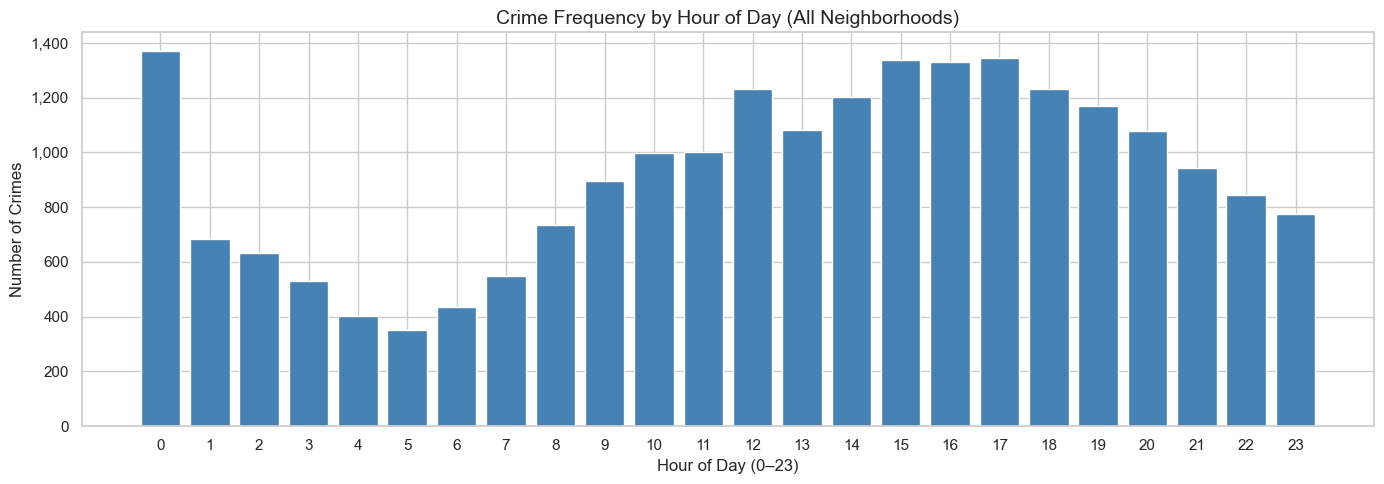

In [19]:
hourly = df.groupby('hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly['hour'], hourly['count'], color='steelblue', width=0.8)
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Number of Crimes')
ax.set_title('Crime Frequency by Hour of Day (All Neighborhoods)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 16. Time of Day by Crime Type
Do different crimes peak at different hours?

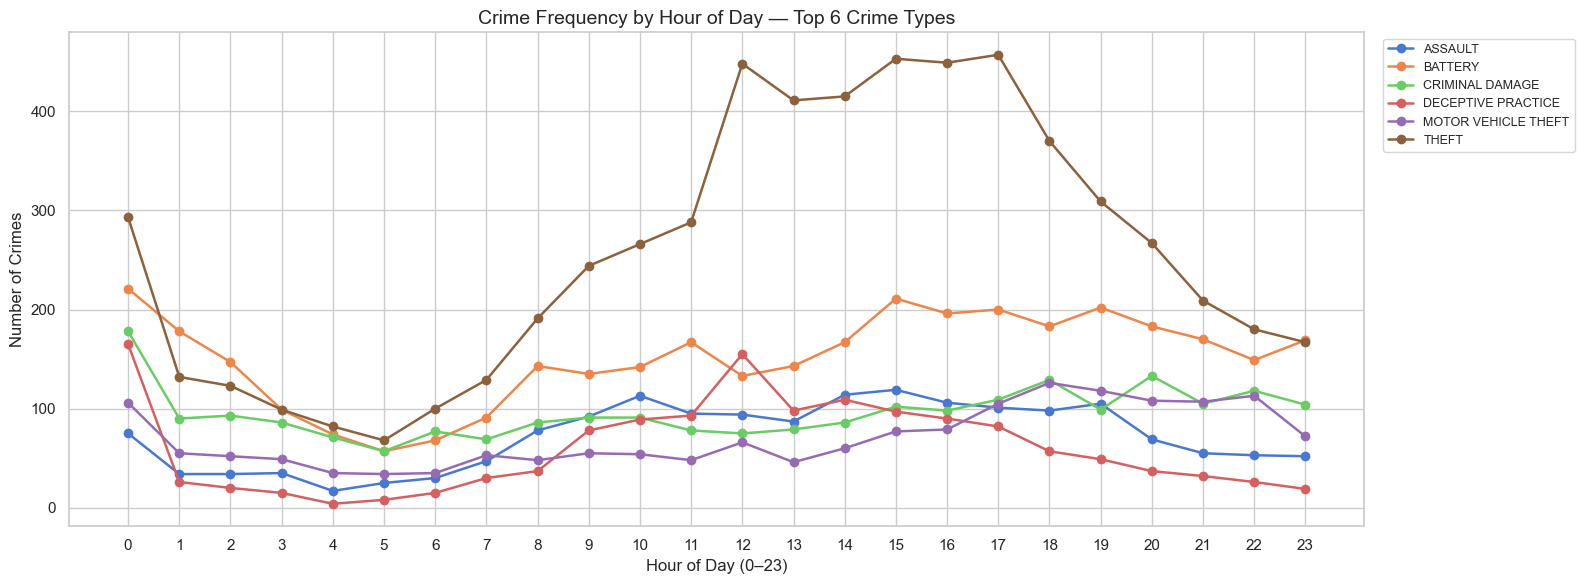

In [20]:
# Pick top 6 crime types to keep the chart readable
top6_types = df['primary_type'].value_counts().head(6).index.tolist()

hour_by_type = (
    df[df['primary_type'].isin(top6_types)]
      .groupby(['hour', 'primary_type'])
      .size()
      .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(16, 6))
for crime_type, grp in hour_by_type.groupby('primary_type'):
    ax.plot(grp['hour'], grp['count'], marker='o', label=crime_type, linewidth=1.8)

ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Number of Crimes')
ax.set_title('Crime Frequency by Hour of Day — Top 6 Crime Types')
ax.set_xticks(range(0, 24))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 17. Crime by Day of Week

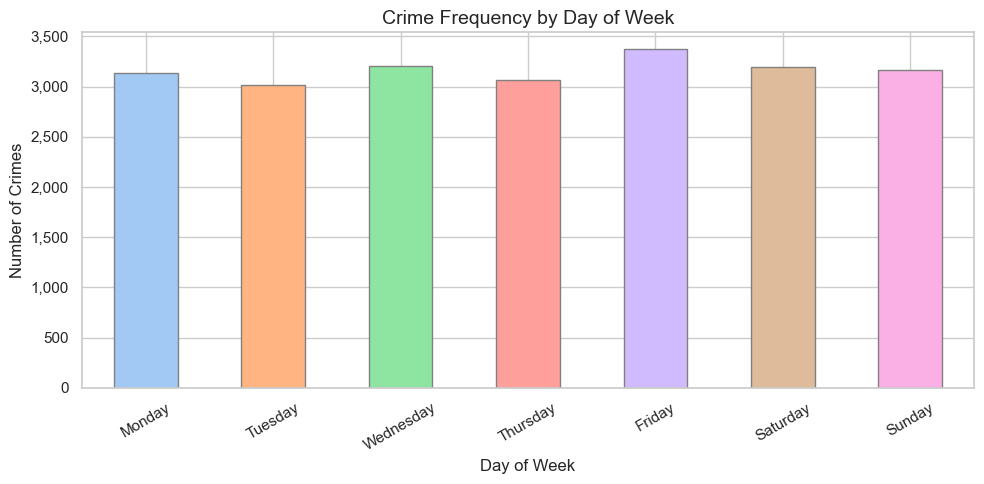

In [21]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df['day_of_week'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
daily.plot(kind='bar', ax=ax, color=sns.color_palette('pastel', 7), edgecolor='grey')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Crimes')
ax.set_title('Crime Frequency by Day of Week')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 18. Weekend vs. Weekday Crime Comparison

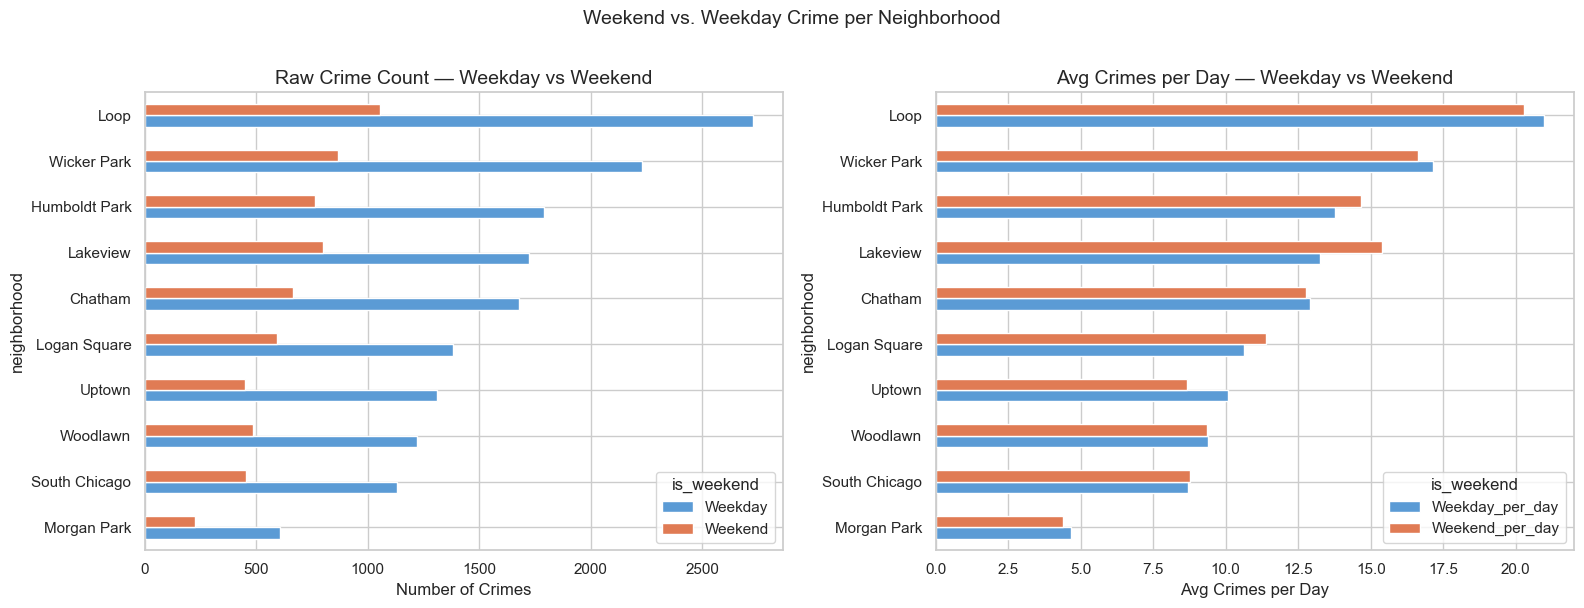

In [22]:
weekend_summary = (
    df.groupby(['neighborhood', 'is_weekend'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={False: 'Weekday', True: 'Weekend'})
)

# Normalise by number of days so the comparison is fair
# 6 months ≈ 26 weeks → ~130 weekdays, ~52 weekend days
weekend_summary['Weekday_per_day'] = weekend_summary['Weekday'] / 130
weekend_summary['Weekend_per_day'] = weekend_summary['Weekend'] / 52

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
weekend_summary[['Weekday', 'Weekend']].sort_values('Weekday').plot(
    kind='barh', ax=axes[0], color=['#5b9bd5', '#e07b54']
)
axes[0].set_title('Raw Crime Count — Weekday vs Weekend')
axes[0].set_xlabel('Number of Crimes')

# Per day average
weekend_summary[['Weekday_per_day', 'Weekend_per_day']].sort_values('Weekday_per_day').plot(
    kind='barh', ax=axes[1], color=['#5b9bd5', '#e07b54']
)
axes[1].set_title('Avg Crimes per Day — Weekday vs Weekend')
axes[1].set_xlabel('Avg Crimes per Day')

plt.suptitle('Weekend vs. Weekday Crime per Neighborhood', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 19. Top Location Descriptions (Where Crimes Happen)

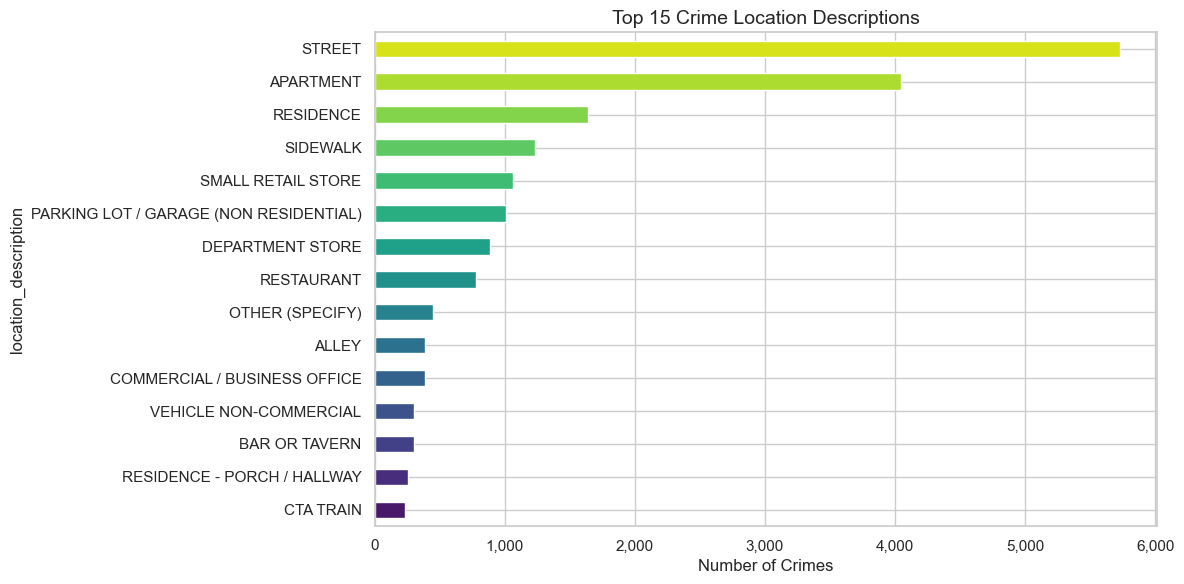

In [23]:
top_locations = df['location_description'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
top_locations.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 15))
ax.set_xlabel('Number of Crimes')
ax.set_title('Top 15 Crime Location Descriptions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 20. Crime Type by Location Description
Which locations are associated with which types of crimes?

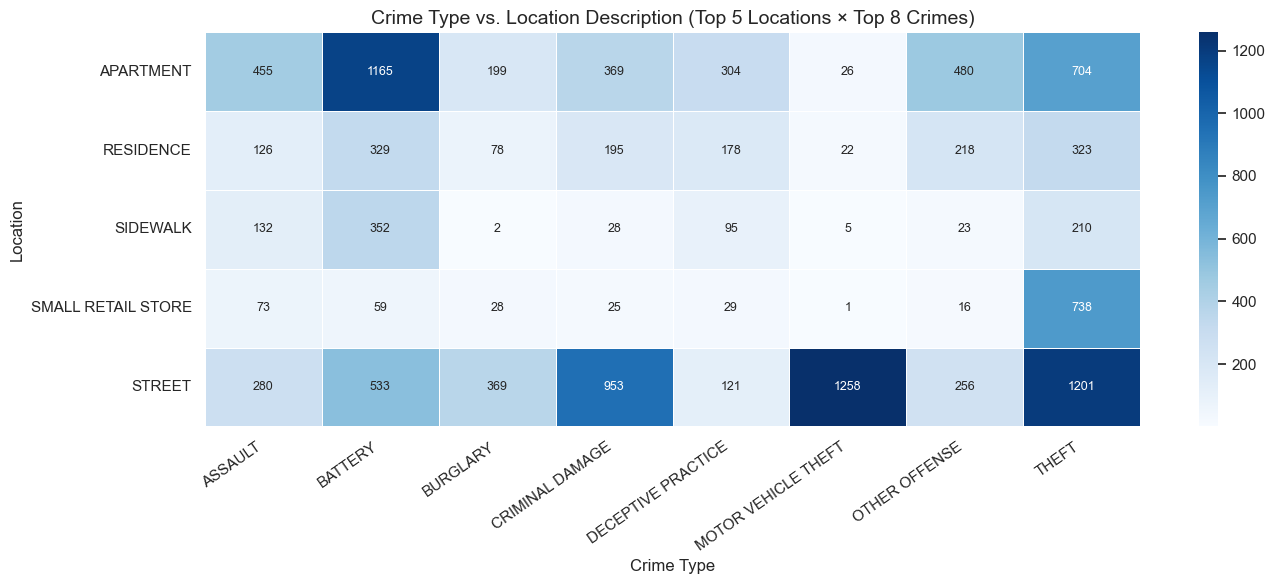

In [24]:
top5_locs   = df['location_description'].value_counts().head(5).index
top5_crimes = df['primary_type'].value_counts().head(8).index

loc_crime = (
    df[df['location_description'].isin(top5_locs) & df['primary_type'].isin(top5_crimes)]
      .groupby(['location_description', 'primary_type'])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    loc_crime, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Crime Type vs. Location Description (Top 5 Locations × Top 8 Crimes)')
ax.set_xlabel('Crime Type')
ax.set_ylabel('Location')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 21. Top Crime-Prone Blocks / Streets

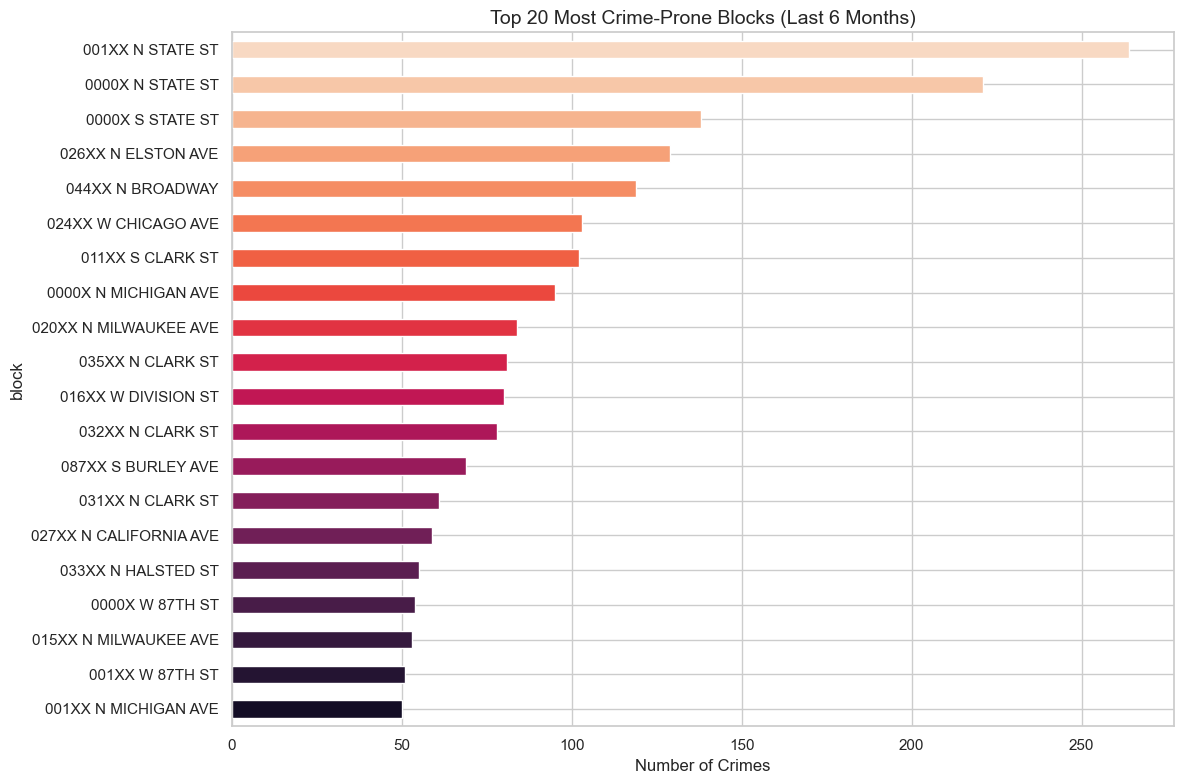

In [25]:
top_blocks = df['block'].value_counts().head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
top_blocks.plot(kind='barh', ax=ax, color=sns.color_palette('rocket', 20))
ax.set_xlabel('Number of Crimes')
ax.set_title('Top 20 Most Crime-Prone Blocks (Last 6 Months)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 22. Top Blocks per Neighborhood

In [26]:
top_block_per_hood = (
    df.groupby(['neighborhood', 'block'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .groupby('neighborhood')
      .head(3)                          # top 3 blocks per neighborhood
      .sort_values(['neighborhood', 'count'], ascending=[True, False])
)

print(top_block_per_hood.to_string(index=False))

 neighborhood                     block  count
      Chatham           0000X W 87TH ST     54
      Chatham           001XX W 87TH ST     51
      Chatham 083XX S COTTAGE GROVE AVE     45
Humboldt Park        016XX N PULASKI RD     36
Humboldt Park       033XX W CHICAGO AVE     34
Humboldt Park   007XX N SACRAMENTO BLVD     34
     Lakeview          035XX N CLARK ST     81
     Lakeview          032XX N CLARK ST     78
     Lakeview          031XX N CLARK ST     61
 Logan Square        026XX N ELSTON AVE    129
 Logan Square     020XX N MILWAUKEE AVE     84
 Logan Square    027XX N CALIFORNIA AVE     59
         Loop          001XX N STATE ST    264
         Loop          0000X N STATE ST    221
         Loop          0000X S STATE ST    138
  Morgan Park    117XX S MARSHFIELD AVE     47
  Morgan Park       118XX S WESTERN AVE     25
  Morgan Park      111XX S HOMEWOOD AVE     17
South Chicago        087XX S BURLEY AVE     69
South Chicago        088XX S BURLEY AVE     50
South Chicago

## 23. Correlation Heatmap (Numeric Features)

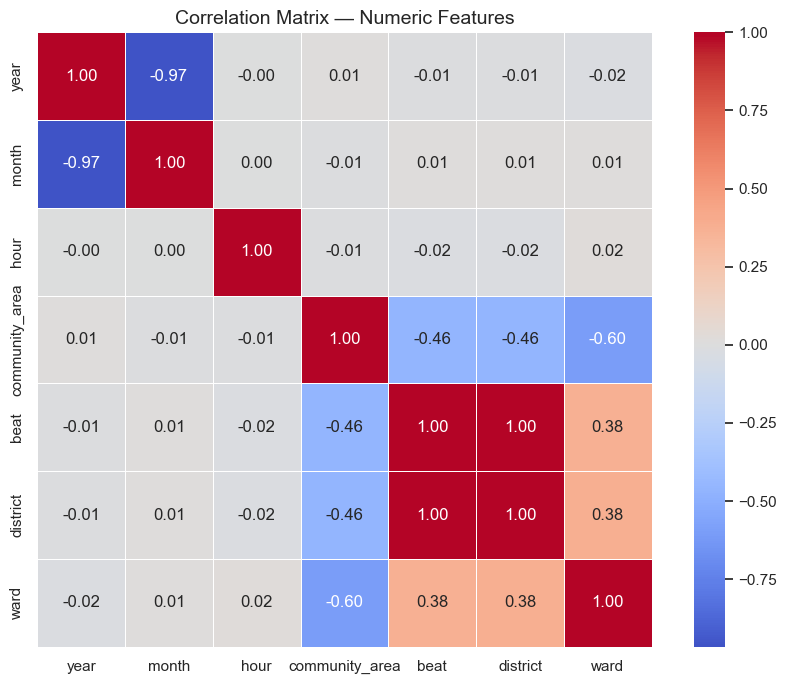

In [27]:
numeric_cols = ['year', 'month', 'hour', 'community_area', 'beat', 'district', 'ward']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

## 24. Summary Statistics Table

In [28]:
summary = (
    df.groupby('neighborhood')
      .agg(
          total_crimes       = ('date', 'count'),
          arrests            = ('arrest', 'sum'),
          domestic_crimes    = ('domestic', 'sum'),
          unique_crime_types = ('primary_type', 'nunique'),
          unique_blocks      = ('block', 'nunique'),
          date_min           = ('date', 'min'),
          date_max           = ('date', 'max'),
      )
      .reset_index()
)
summary['arrest_rate_%']   = (summary['arrests']         / summary['total_crimes'] * 100).round(2)
summary['domestic_rate_%'] = (summary['domestic_crimes'] / summary['total_crimes'] * 100).round(2)
summary = summary.sort_values('total_crimes', ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
print(summary.to_string(index=False))

 neighborhood  total_crimes  arrests  domestic_crimes  unique_crime_types  unique_blocks            date_min            date_max  arrest_rate_%  domestic_rate_%
         Loop          3779      740              138                  27            276 2025-08-29 00:20:00 2026-02-16 21:53:00          19.58             3.65
  Wicker Park          3096      243              250                  25            690 2025-08-29 00:13:00 2026-02-17 00:00:00           7.85             8.07
Humboldt Park          2555      684              500                  24            467 2025-08-29 00:00:00 2026-02-16 23:13:00          26.77            19.57
     Lakeview          2521      212              129                  23            446 2025-08-29 01:10:00 2026-02-17 00:00:00           8.41             5.12
      Chatham          2340      318              625                  22            364 2025-08-29 00:35:00 2026-02-16 22:00:00          13.59            26.71
 Logan Square          1973      3

## 25. Export Cleaned Data

In [ ]:
out_path = '../data/chicago_crimes_neighborhoods.csv'
df.to_csv(out_path, index=False)
print(f'Cleaned data saved to : {out_path}')
print(f'Shape                 : {df.shape}')